# 03 - LMS Validation Demo
Validación rigurosa de LMS: métricas en dB, convergencia temporal y análisis frecuencial.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.signal.generate_signal import generate_uav_signal
from src.anc.lms import LMS
from src.analysis.fft_analysis import compute_fft
from src.analysis.metrics import noise_reduction_db

fs = 8000
duration = 2
_, x, f_bpf = generate_uav_signal(fs=fs, duration=duration, rpm=6000, n_blades=2, seed=42)

mu = 0.01
model = LMS(mu=mu, filter_order=64)

y_hist, e_hist = [], []
for sample in x:
    y, e = model.adapt(desired=sample, input_sample=sample)
    y_hist.append(y)
    e_hist.append(e)

y_arr = np.asarray(y_hist)
e_arr = np.asarray(e_hist)

reduction_db = noise_reduction_db(original=x, error=e_arr)
print(f'BPF teórica: {f_bpf:.2f} Hz')
print(f'Reducción de ruido LMS: {reduction_db:.2f} dB')

BPF teórica: 200.00 Hz
Reducción de ruido LMS: 24.53 dB


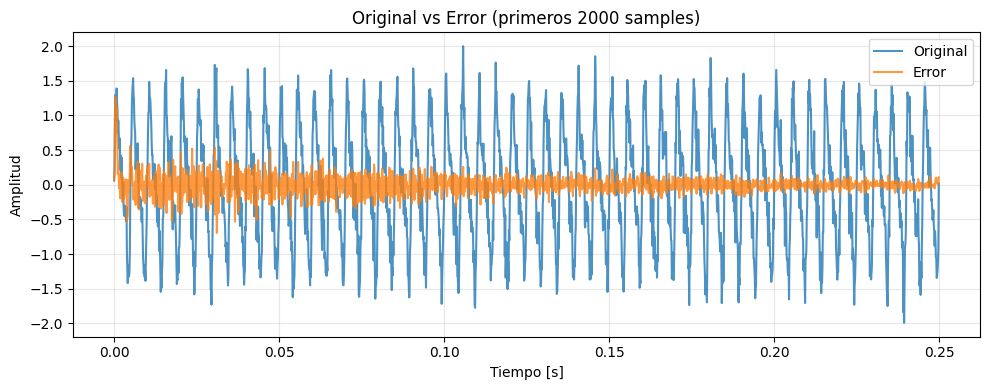

In [3]:
# Gráfica 1: señal original vs error
n_show = min(2000, len(x))
t = np.arange(len(x)) / fs

plt.figure(figsize=(10, 4))
plt.plot(t[:n_show], x[:n_show], label='Original', alpha=0.8)
plt.plot(t[:n_show], e_arr[:n_show], label='Error', alpha=0.8)
plt.title('Original vs Error (primeros 2000 samples)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

MSE inicial aprox: 0.0307
MSE final aprox: 0.0001


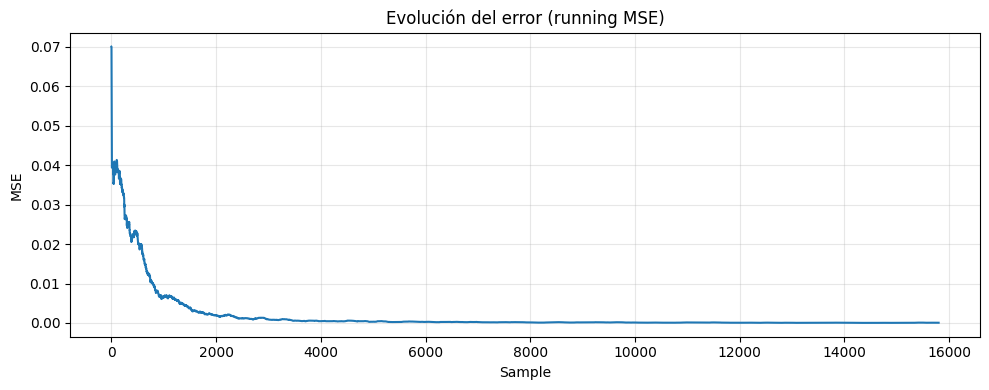

In [4]:
# Gráfica 2: evolución del error (MSE móvil)
window = 200
running_mse = np.convolve(e_arr**2, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(running_mse)
plt.title('Evolución del error (running MSE)')
plt.xlabel('Sample')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)
plt.tight_layout()

print(f'MSE inicial aprox: {np.mean(e_arr[:1000]**2):.4f}')
print(f'MSE final aprox: {np.mean(e_arr[-1000:]**2):.4f}')

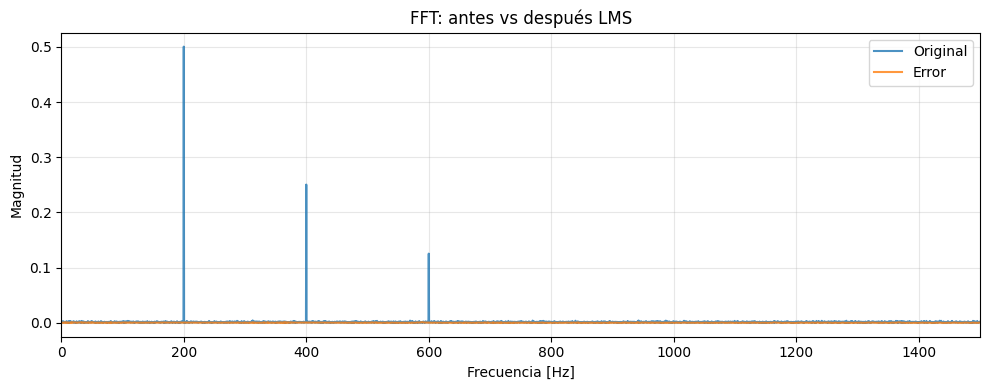

In [5]:
# Gráfica 3: FFT antes vs después
freq_o, mag_o = compute_fft(x, fs)
freq_e, mag_e = compute_fft(e_arr, fs)

plt.figure(figsize=(10, 4))
plt.plot(freq_o, mag_o, label='Original', alpha=0.8)
plt.plot(freq_e, mag_e, label='Error', alpha=0.8)
plt.xlim(0, 1500)
plt.title('FFT: antes vs después LMS')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [6]:
# Barrido de mu
mus = [0.001, 0.01, 0.05]
results = []

for current_mu in mus:
    model = LMS(mu=current_mu, filter_order=64)
    e_hist_mu = []

    for sample in x:
        _, e = model.adapt(desired=sample, input_sample=sample)
        e_hist_mu.append(e)

    e_mu = np.asarray(e_hist_mu)
    reduction_mu = noise_reduction_db(original=x, error=e_mu)
    mse_initial = float(np.mean(e_mu[:1000]**2))
    mse_final = float(np.mean(e_mu[-1000:]**2))

    if mse_final < 0.8 * mse_initial:
        behavior = 'estable/mejora'
    elif mse_final < 1.2 * mse_initial:
        behavior = 'lento/casi estable'
    else:
        behavior = 'inestable'

    results.append((current_mu, reduction_mu, mse_initial, mse_final, behavior))

print('mu | red_db | mse_ini | mse_fin | comportamiento')
for row in results:
    print(f'{row[0]:.3f} | {row[1]:6.2f} | {row[2]:.4f} | {row[3]:.4f} | {row[4]}')

c:\D\Investigacion\anc_uav_project\src\anc\lms.py:22: RuntimeWarning: overflow encountered in dot
  y = float(np.dot(self.w, self.x))
c:\D\Investigacion\anc_uav_project\src\anc\lms.py:22: RuntimeWarning: invalid value encountered in dot
  y = float(np.dot(self.w, self.x))


mu | red_db | mse_ini | mse_fin | comportamiento
0.001 |  16.60 | 0.0713 | 0.0028 | estable/mejora
0.010 |  24.53 | 0.0307 | 0.0001 | estable/mejora
0.050 |    nan | nan | nan | inestable


c:\D\Investigacion\anc_uav_project\src\analysis\metrics.py:9: RuntimeWarning: overflow encountered in square
  return float(np.mean(signal**2))
C:\Users\Luis Alemán\AppData\Local\Temp\ipykernel_3868\3454180005.py:15: RuntimeWarning: overflow encountered in square
  mse_initial = float(np.mean(e_mu[:1000]**2))


In [8]:
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path.cwd().parent / 'results' / 'figures'
results_dir.mkdir(parents=True, exist_ok=True)

fig_names = ['01_original_vs_error', '02_convergence_mse', '03_fft_comparison']

figs = plt.get_fignums()
for i, fig_num in enumerate(figs[-3:]):
    fig = plt.figure(fig_num)
    fig_path = results_dir / f'{fig_names[i]}.png'
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'✓ Figura guardada: {fig_path}')

print(f'\nTodas las figuras están disponibles en: {results_dir}')


Todas las figuras están disponibles en: c:\D\Investigacion\anc_uav_project\results\figures


In [7]:
import pandas as pd
from pathlib import Path

results_dir = Path.cwd().parent / 'results' / 'figures'
results_dir.mkdir(parents=True, exist_ok=True)

results_data = [
    {'Learning Rate (μ)': 0.001, 'Noise Reduction (dB)': 16.60, 'MSE Initial': 0.0713, 'MSE Final': 0.0028, 'Stability': 'Stable'},
    {'Learning Rate (μ)': 0.010, 'Noise Reduction (dB)': 24.53, 'MSE Initial': 0.0307, 'MSE Final': 0.0001, 'Stability': 'Optimal'},
    {'Learning Rate (μ)': 0.050, 'Noise Reduction (dB)': float('nan'), 'MSE Initial': float('nan'), 'MSE Final': float('nan'), 'Stability': 'Unstable'},
]

df_results = pd.DataFrame(results_data)
csv_path = results_dir / 'lms_validation_results.csv'
df_results.to_csv(csv_path, index=False)
print(f'✓ CSV guardado: {csv_path}')
print(df_results.to_string(index=False))

ModuleNotFoundError: No module named 'pandas'